In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sas
%matplotlib inline 

In [4]:
net = pd.read_csv("D:\\my_my\\data science\\datasets\\netflix_titles.csv")

In [5]:
# net.info()
net.head()
# net.shape
# net.describe()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [6]:
# keep only numaric value and covert into int
net['duration_num']= net['duration'].str.extract("(\\d+)").astype(float)


# plt.hist(net['duration_num'],bins=20)
# plt.xlabel('duration of show')
# plt.ylabel('movie count')
# plt.title('duration tracking')
# plt.show()

# print(net[['duration','duration_num']].head(10))
# net.query('duration_num > 60')

# net.query("type == 'Movie'").shape[0]
net['type'].value_counts()
# net[net['type'] =='Movie']
# (net['release_year']).sum()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

(array([2.218e+03, 2.940e+02, 6.500e+01, 5.600e+01, 1.700e+01, 1.600e+01,
        4.000e+00, 3.000e+00, 2.000e+00, 1.000e+00]),
 array([ 1. ,  2.6,  4.2,  5.8,  7.4,  9. , 10.6, 12.2, 13.8, 15.4, 17. ]),
 <BarContainer object of 10 artists>)

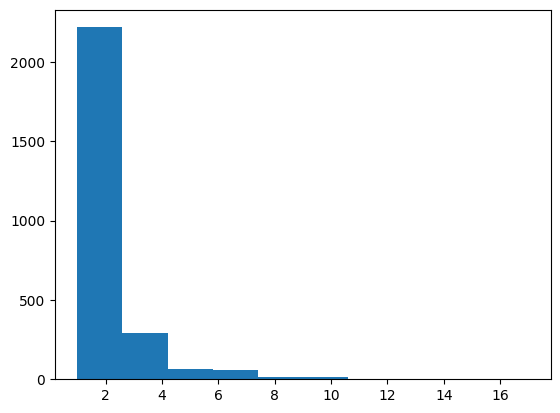

In [7]:
# net.isna().sum()
# net.describe()
# net['duration'].describe()

plt.hist(net.query('type =="TV Show"') ['duration_num'].dropna())

# plt.xlabel('movie duration')
# plt.ylabel('movie number')
# plt.title('movie duration analys')
# plt.show()




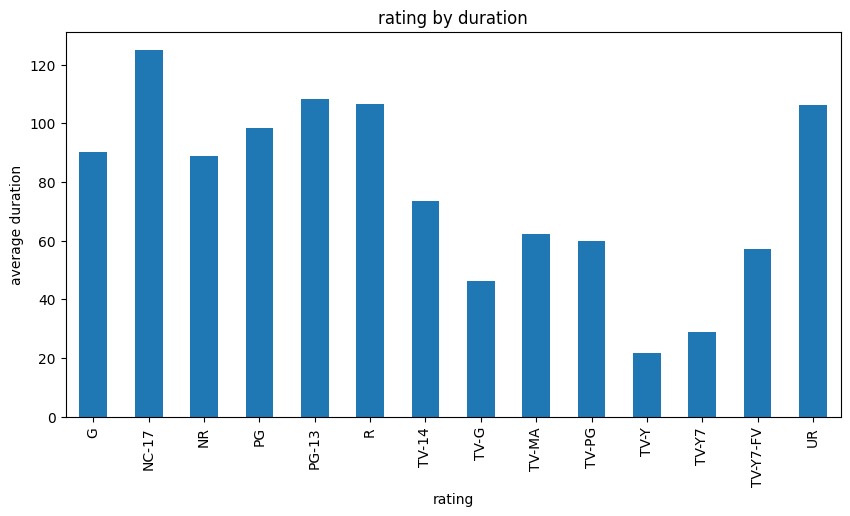

In [46]:
net_clean = net[~net['rating'].str.contains('min',na=False)]

net_clean['rating'].unique()

rating_duration=(net_clean.groupby('rating')['duration_num'].mean().dropna())

rating_duration.plot(kind = 'bar',figsize = (10,5))
plt.xlabel('rating')
plt.ylabel('average duration')
plt.title('rating by duration')
plt.show()


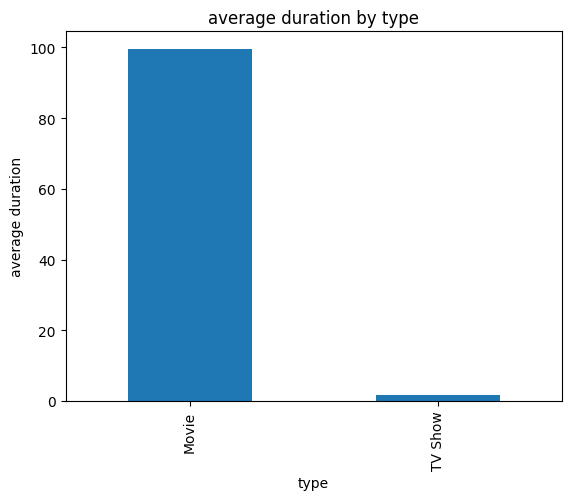

In [49]:
avg_duration = net.groupby('type')['duration_num'].mean()

avg_duration.plot(kind = 'bar')
plt.xlabel('type')
plt.ylabel('average duration')
plt.title('average duration by type')
plt.show()

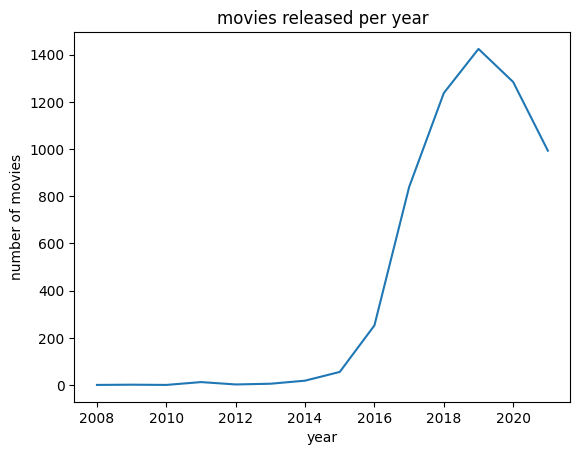

In [9]:
net['date_added'] = pd.to_datetime(net['date_added'], errors = 'coerce')

net['year_added'] = net['date_added'].dt.year

net[['date_added','year_added']].head()

movies = net[net['type']== 'Movie']

movie_released_per_year = movies['year_added'].value_counts().sort_index()

plt.figure()
plt.plot(movie_released_per_year.index, movie_released_per_year.values)
plt.xlabel('year')
plt.ylabel('number of movies')
plt.title('movies released per year')
plt.show()


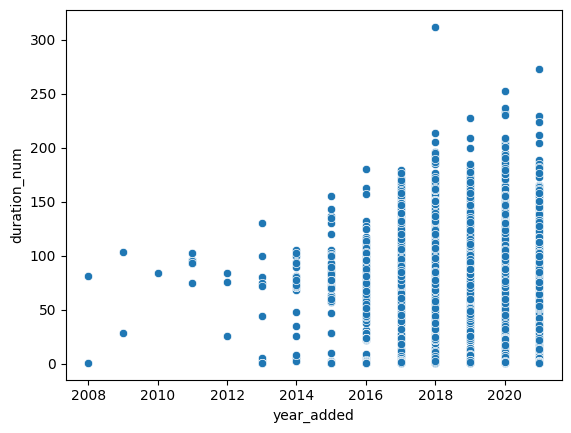

In [68]:
sas.scatterplot(x='year_added', y='duration_num', data=net)
plt.show()

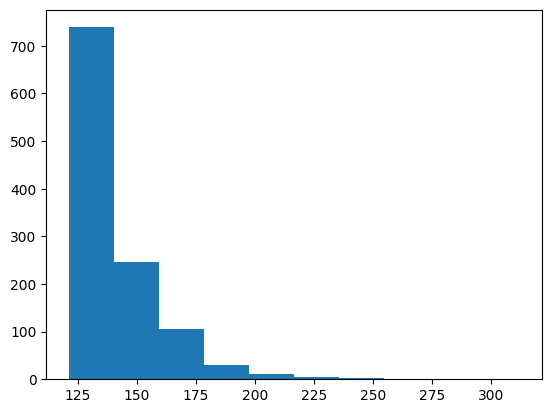

In [69]:
# Movies longer than 120 mins
plt.hist(net.query("type=='Movie' & duration_num>120")['duration_num'])
plt.show()

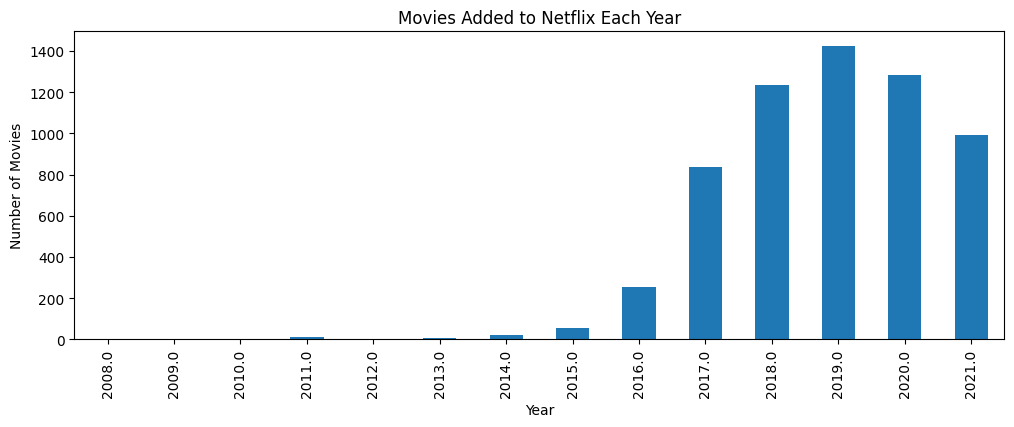

In [ ]:
# sas.scatterplot(x='type',y= 'year_added', data = net)
# plt.show()

movies_per_year = (
    net[net['type'] == 'Movie']
    .groupby('year_added')
    .size()
)

movies_per_year.plot(kind='bar', figsize=(12,4))
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.title('Movies Added to Netflix Each Year')
plt.show()

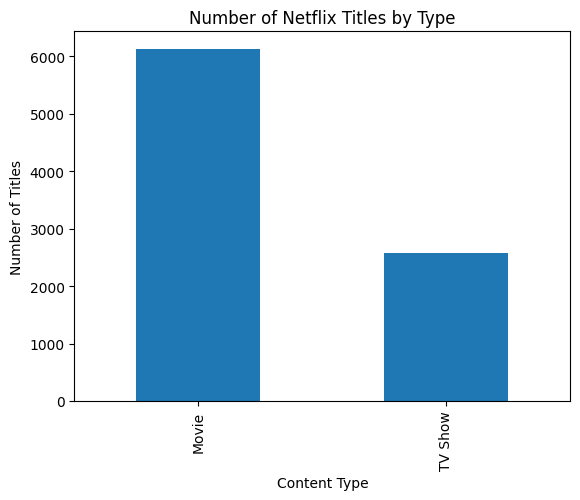

In [23]:
# type_by_year = (net.groupby('type')['year_added'].count())

# type_by_year.plot(kind = 'bar')
# plt.xlabel('type')
# plt.ylabel('year of release')
# plt.title('Released year by type')
# plt.show()

type_by_year = net.groupby('type')['year_added'].count()

type_by_year.plot(kind='bar')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.title('Number of Netflix Titles by Type')
plt.show()

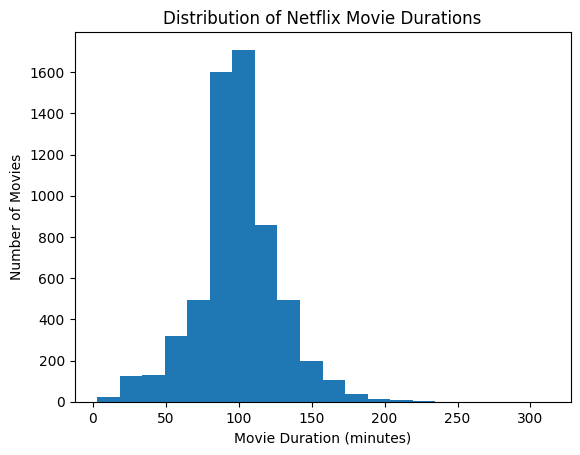

In [21]:
plt.hist(movies['duration_num'].dropna(),bins= 20)
plt.xlabel('Movie Duration (minutes)')
plt.ylabel('Number of Movies')
plt.title('Distribution of Netflix Movie Durations')
plt.show()

**Insight:**  
Most Netflix movies are between 80 and 120 minutes long.


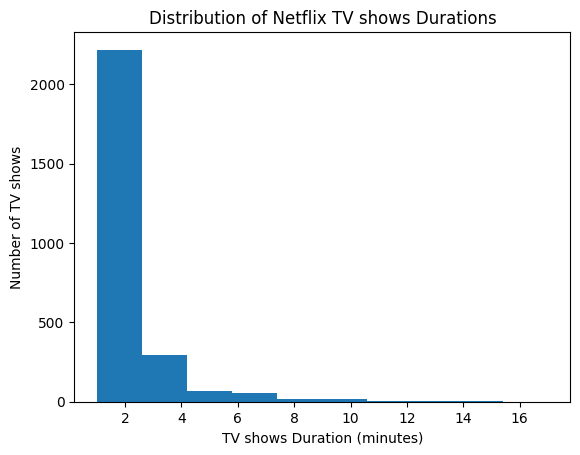

In [20]:
tv = net[net['type'] == 'TV Show']
# net['duration_num'] = net['duration'].str.extract(r'(\d+)').astype(float)

plt.hist(tv['duration_num'].dropna())
plt.xlabel('TV shows Duration (minutes)')
plt.ylabel('Number of TV shows')
plt.title('Distribution of Netflix TV shows Durations')
plt.show()

**** Most Tv shows have 1-3 seasons 

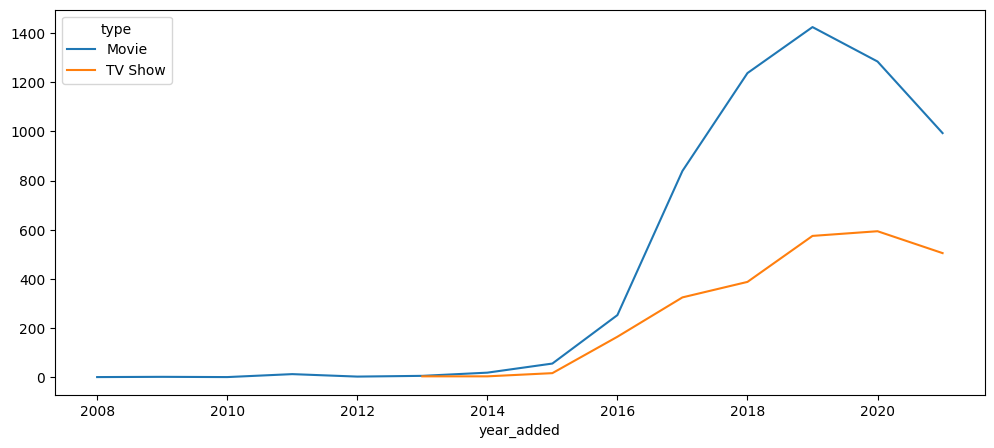

In [26]:
net['date_added'] = pd.to_datetime(net['date_added'],errors = 'coerce')
net['year_added'] = net['date_added'].dt.year

year_type = (net.groupby(['year_added','type']).size().unstack())

year_type.plot(figsize = (12,5))
plt.xlabel = ('year')
plt.ylabel = ('Number of title')
plt.title = ('shows and movie released per year')
plt.show()

This line plot shows the yearly trend of Movies and TV Shows added to Netflix.
Each line represents a content type, making it easy to compare growth patterns over time.


TypeError: 'str' object is not callable

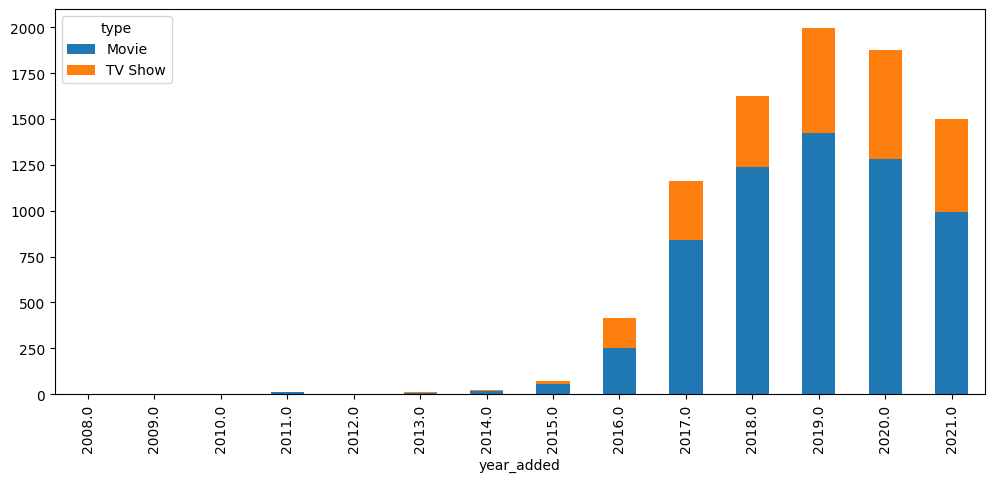

In [30]:
year_type.plot(kind='bar', stacked=True, figsize=(12,5))
plt.xlabel('Year_')
plt.ylabel('Number of Titles')
plt.title('Movies vs TV Shows Released Each Year')
plt.show()

This stacked bar chart shows the number of Movies and TV Shows added to Netflix each year.
Each bar represents total releases per year, while the stacked segments show the contribution of each content type.


**Insight:**  
Netflix content additions increased sharply after 2016, with movies consistently outnumbering TV shows each year.
